# NEW ZEALAND’S TRANSPORT EMISSION AND EFFICIENCY

New Zealand is committed to reducing its Greenhouse gas (GHG) emissions under international and national climate agreements.  
Among all sectors, **transport remains one of the largest contributors to GHG emissions**, yet it remains unclear whether efforts to improve emissions efficiency are producing meaningful results.

To better understand New Zealand’s position, we structure this analysis around **four key questions**:

1. **What is New Zealand's Greenhouse Gas Emissions intensity (GHGs / GDP) compared to other OECD members?**  
2. **What is the relationship between New Zealand’s transport emissions and its energy consumption compared to other OECD members?**  
3. **How efficient is New Zealand’s emissions payoff in the transport sector compared to other OECD countries?**  
4. **How have the best-performing countries managed to reduce and control their transport emissions effectively through innovations?**  

While the first three questions are answered using our selected combined datasets, the **fourth question required additional data** which are not available in our combined dataset.  
To explore how top countries are innovating, we applied **web scraping techniques** to collect real-world data on climate-related patents and green transport technologies.  
This allowed us to identify actionable insights and opportunities for New Zealand.

###  1. DATA SOURCE
All datasets were retrieved from the **[OECD Data Explorer](https://data-explorer.oecd.org/)**, covering all **38 OECD member countries**.

---

#### 1.1 [Greenhouse Gas Emissions Inventories](https://drive.google.com/file/d/1g5BpzVzjUIK1WvR4ZIMb7x3b2GCdps9O/view?usp=sharing) (GHG Dataset)

**Source: [Air emissions - Greenhouse gas emissions Inventories  - OECD Data Explorer](https://shorturl.at/VDRRO)**

**Natural state of the dataset:**
- ***Pollutant***: Greenhouse gases (GHGs) across all activity sectors  
- ***Unit of Measure***: Tonnes of CO₂-equivalent (in thousands)  
- ***Activity Sectors***:  
  - Total emissions excluding land use, land-use change and forestry (LULUCF)  
  - Total emissions including land use, land-use change and forestry (LULUCF)  
  - Land use, land-use change and forestry  
  - Agriculture  
  - Transport  
  - Industrial processes and product use  
  - Energy – Other  
  - Manufacturing industries and construction  
  - Waste  
  - Energy industries  
  - Other sectors  
  - Fugitive emissions from fuels  
  - Residential and other sectors  
  - CO₂ transport and storage  
 

In [1]:
# Import the data: Greenhouse Gas Emissions Inventory Data
import pandas as pd
pd.set_option('display.max_columns', None)

ghg = pd.read_csv('OECD_GHG_Dataset.csv')

# Quick structure audit
ghg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15218 entries, 0 to 15217
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   STRUCTURE                 15218 non-null  object 
 1   STRUCTURE_ID              15218 non-null  object 
 2   STRUCTURE_NAME            15218 non-null  object 
 3   ACTION                    15218 non-null  object 
 4   REF_AREA                  15218 non-null  object 
 5   Reference area            15218 non-null  object 
 6   FREQ                      15218 non-null  object 
 7   Frequency of observation  15218 non-null  object 
 8   POLLUTANT                 15218 non-null  object 
 9   Pollutant                 15218 non-null  object 
 10  MEASURE                   15218 non-null  object 
 11  Measure                   15218 non-null  object 
 12  UNIT_MEASURE              15218 non-null  object 
 13  Unit of measure           15218 non-null  object 
 14  TIME_P

In [2]:
## Generate descriptive statistics for all columns, including categorical ones
ghg.describe(include='all')

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,POLLUTANT,Pollutant,MEASURE,Measure,UNIT_MEASURE,Unit of measure,TIME_PERIOD,Time period,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,PRICE_BASE,Price base,BASE_PER,Base period,DECIMALS,Decimals,CONVERSION_TYPE,Conversion type
count,15218,15218,15218,15218,15218,15218,15218,15218,15218,15218,15218,15218,15218,15218,15218.000000,0.0,1.510200e+04,0.0,15218,15218,15218.0,15218,0.0,0.0,0.0,0.0,15218.0,15218,0.0,0.0
unique,1,1,1,1,38,38,1,1,1,1,14,14,1,1,NaN,NaN,NaN,NaN,4,4,NaN,1,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN
top,DATAFLOW,OECD.ENV.EPI:DSD_AIR_GHG@DF_AIR_GHG(1.0),Air emissions - Greenhouse gas emissions Inven...,I,HUN,Hungary,A,Annual,GHG,Greenhouse gases,_T,"Total emissions excluding land use, land-use c...",T_CO2E,Tonnes of CO2-equivalent,NaN,NaN,NaN,NaN,A,Normal value,NaN,Thousands,NaN,NaN,NaN,NaN,NaN,Two,NaN,NaN
freq,15218,15218,15218,15218,494,494,15218,15218,15218,15218,1239,1239,15218,15218,NaN,NaN,NaN,NaN,15042,15042,NaN,15218,NaN,NaN,NaN,NaN,NaN,15218,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005.747930,NaN,9.861587e+04,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.545556,NaN,4.734178e+05,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1985.000000,NaN,-8.871841e+05,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1998.000000,NaN,1.163048e+03,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006.000000,NaN,1.014313e+04,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.000000,NaN,5.298333e+04,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN


In [3]:
# Determine how many distinct GHG measurement types are present in the dataset
ghg["Measure"].unique()

array(['Industrial processes and product use',
       'Total emissions excluding land use, land-use change and forestry',
       'Total emissions including land use, land-use change and forestry',
       'Energy industries', 'Manufacturing industries and construction',
       'Agriculture', 'Energy-other', 'Transport',
       'Land use, land-use change and forestry',
       'Residential and other sectors', 'Other sectors', 'Waste',
       'Fugitive emissions from fuels', 'CO2 transport and storage'],
      dtype=object)

In [4]:
# Determine how many distinct Observation status are present in the dataset
ghg["Observation status"].unique()

array(['Normal value', 'Estimated value', 'Time series break',
       'Not significant'], dtype=object)


##### General Characteristics of GHG Dataset
- **Format**: CSV file  
- **Structure**:  
  - Size: 15,218 rows × 30 columns  
  - Countries Covered: 38 OECD member countries  
  - Measures Included: 14 different greenhouse gas (GHG) activity sectors  
    (e.g., Transport, Agriculture, Energy Industries, Waste)

---

##### Initial Audit

- The dataset follows a **metadata-rich OECD schema**. Many columns contain constant or repeated values  
  (e.g., `STRUCTURE_ID`, `ACTION`, `FREQ`, `POLLUTANT`).

- Several columns appear **redundant**, such as:
  - `REF_AREA` and `Reference area` both refer to country identifiers.
  - `TIME_PERIOD` and `Year` (after renaming) represent the same time dimension.

- **Non-essential metadata columns** (e.g., `UNIT_MULT`, `PRICE_BASE`, `CONVERSION_TYPE`)  
  will be excluded due to lack of analytical relevance or consistency.

- The actual **emission values are stored in the `OBS_VALUE` column**, which must be  
  **pivoted by `Measure`** (i.e., GHG activity sector) to prepare the dataset for analysis.

- Some fields contain `NaN` values, mostly in metadata columns. These **do not affect core analytical columns**.

- **Unit Note**: Emissions are measured in **thousands of tonnes CO₂-equivalent** (`UNIT_MULT = 3`).

- **All observation statuses are retained** to ensure data completeness.  
  The dataset includes 4 distinct `Observation status` values:
  - `'Normal value'`: Officially reported value  
  - `'Estimated value'`: Derived via estimation  
  - `'Time series break'`: Indicates data discontinuity  
  - `'Not significant'`: Too minor or uncertain to influence results independently

---

> **Key columns selected for analysis**:  
> `'REF_AREA'`, `'Reference area'`, `'Measure'`, `'TIME_PERIOD'`, `'OBS_VALUE'`



#### 1.2 [OECD Green Growth](https://drive.google.com/file/d/1K0DSQlcsey89JMZ5BwjJK8wjB4ClkCB2/view?usp=sharing) (GG Dataset)

**Sources: [Green Growth - OECD Data Explorer](https://shorturl.at/tCpVQ)**

**Natural state of the dataset:**
- **Measures**:  
  - Real GDP (total across all activity)  
  - Energy consumption across economic sectors  
- **Units of Measure**:  
  - Real GDP: Millions of US dollars, PPP-adjusted  
  - Energy consumption: Percentage of total energy use  
- **Economic Activity Categories**:  
  - Agriculture, forestry and fishing  
  - Industry (excluding construction)  
  - Services  
  - Transportation and storage  
  - Other

In [5]:
# Import the data: Green Growth Indicators (includes GDP, energy consumption)
gg = pd.read_csv('OECD_GreenGrowth.csv')
# Quick structure audit
gg.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2280 entries, 0 to 2279
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   STRUCTURE                 2280 non-null   object 
 1   STRUCTURE_ID              2280 non-null   object 
 2   STRUCTURE_NAME            2280 non-null   object 
 3   ACTION                    2280 non-null   object 
 4   REF_AREA                  2280 non-null   object 
 5   Reference area            2280 non-null   object 
 6   FREQ                      2280 non-null   object 
 7   Frequency of observation  2280 non-null   object 
 8   MEASURE                   2280 non-null   object 
 9   Measure                   2280 non-null   object 
 10  UNIT_MEASURE              2280 non-null   object 
 11  Unit of measure           2280 non-null   object 
 12  ACTIVITY                  2280 non-null   object 
 13  Economic activity         2280 non-null   object 
 14  TIME_PER

In [6]:
## Generate descriptive statistics for all columns, including categorical ones
gg.describe(include='all') 

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,UNIT_MEASURE,Unit of measure,ACTIVITY,Economic activity,TIME_PERIOD,Time period,OBS_VALUE,Observation value,OBS_STATUS,Observation status,OBS_STATUS_2,Observation status 2,UNIT_MULT,Unit multiplier,PRICE_BASE,Price base,BASE_PER,Base period,TIMELINESS,Timeliness,DECIMALS,Decimals
count,2280,2280,2280,2280,2280,2280,2280,2280,2280,2280,2280,2280,2280,2280,2280.000000,0.0,2.280000e+03,0.0,2280,2280,0.0,0.0,2280.000000,2280,2280,2280,380.0,0.0,2280.000000,2280,2280.0,2280
unique,1,1,1,1,38,38,1,1,2,2,2,2,6,6,NaN,NaN,NaN,NaN,1,1,NaN,NaN,NaN,2,2,2,NaN,NaN,NaN,2,NaN,1
top,DATAFLOW,OECD.ENV.EPI:DSD_GG@DF_GREEN_GROWTH(1.1),Green Growth,I,AUS,Australia,A,Annual,NRGC,Energy consumption,PT_CONS_NRG,Percentage of energy consumption,_T,Total - all activities,NaN,NaN,NaN,NaN,A,Normal value,NaN,NaN,NaN,Units,_Z,Not applicable,NaN,NaN,NaN,2 years lag,NaN,Two
freq,2280,2280,2280,2280,60,60,2280,2280,1900,1900,1900,1900,380,380,NaN,NaN,NaN,NaN,2280,2280,NaN,NaN,NaN,1900,1900,1900,NaN,NaN,NaN,1900,NaN,2280
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.500000,NaN,2.742206e+05,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,2020.0,NaN,1.833333,NaN,2.0,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.872911,NaN,1.506916e+06,NaN,NaN,NaN,NaN,NaN,2.236559,NaN,NaN,NaN,0.0,NaN,0.372760,NaN,0.0,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012.000000,NaN,5.200000e-01,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,2020.0,NaN,1.000000,NaN,2.0,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.000000,NaN,1.171000e+01,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,2020.0,NaN,2.000000,NaN,2.0,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.500000,NaN,2.459500e+01,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,2020.0,NaN,2.000000,NaN,2.0,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,3.636250e+01,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,2020.0,NaN,2.000000,NaN,2.0,NaN


In [7]:
# Determine how many distinct GG measurement types are present in the dataset
gg["Measure"].unique()

array(['Real GDP', 'Energy consumption'], dtype=object)

In [8]:
# Determine how many distinct Economic activity are present in the dataset
gg["Economic activity"].unique()

array(['Total - all activities', 'Agriculture, forestry and fishing',
       'Transportation and storage', 'Industry (except construction)',
       'Other', 'Services'], dtype=object)

In [9]:
# Determine how many distinct Price base are present in the dataset
gg["Price base"].unique()

array(['Constant prices', 'Not applicable'], dtype=object)

In [10]:
# Determine how many distinct Unit multiplier are present in the dataset
gg["Unit multiplier"].unique() 

array(['Millions', 'Units'], dtype=object)

In [11]:
# Determine how many distinct Timeliness are present in the dataset
gg["Timeliness"].unique()

array(['1 year lag, timely', '2 years lag'], dtype=object)

##### General Characteristics of GG Dataset:

- **Format**: CSV file  
- **Structure**: 
  - Size: 2,280 rows × 32 columns  
  - Countries covered: 38 OECD members   
  - Measures: 
    - `'Real GDP'` (from economic activity = `'Total - all activities'`)
    - `'Energy consumption'` (from all other activity sectors)
  - Economic activities include:
    - `'Total - all activities'` (Real GDP)
    - `'Agriculture, forestry and fishing'`
    - `'Transportation and storage'`
    - `'Industry (except construction)'`
    - `'Other'`
    - `'Services'`

---
##### Initial Audit:
- The dataset uses a metadata-rich OECD schema, and several columns are **redundant**:
  - `STRUCTURE_ID`, `STRUCTURE_NAME`, `ACTION`, `FREQ`, `UNIT_MEASURE`, and `PRICE_BASE` are the same for all rows and will be dropped.
  - `REF_AREA` and `Reference area` both indicate the country — we keep only one.
  - `TIME_PERIOD` is equivalent to `Year` (after renaming).

- **Two distinct indicators** are captured under the `Measure` column:
  - **Real GDP**: Appears only in rows when `Economic activity` is `'Total - all activities'`
    - Unit: Millions of US dollars (converted to thousands later for consistency)
    - Includes `PRICE_BASE`, `CONVERSION_TYPE`, and `Timeliness` metadata
  - **Energy consumption**: Appears for all other economic activities
    - Unit: Percentage of total energy consumption
- Data must be **pivoted by activity** before merging with other datasets.
---
- **Key columns selected for analysis**:
  - `'REF_AREA'`, `'Reference area'`, `'Economic activity'`, `'TIME_PERIOD'`, `'OBS_VALUE'`



#### 1.3 [Transport Sector – Value Added](https://drive.google.com/file/d/1fIe2wKKATIr4mO0YrFl5Egry9q5JFf6_/view?usp=sharing) (Trans dataset)

**Source: [Transport economic and social indicators - OECD Data Explorer](https://shorturl.at/OUCQe)**

**Natural state of the dataset:**
- **Frequency of Observation**: Annual  
- **Measure**: Value added by the transport sector  
- **Unit of Measure**: Percentage of total value added (by sector)    

In [12]:
# Import the data: Transport Sector Value Added
trans = pd.read_csv('OECD_Transport_Value_Added.csv')
# Quick structure audit
trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   STRUCTURE                 1040 non-null   object 
 1   STRUCTURE_ID              1040 non-null   object 
 2   STRUCTURE_NAME            1040 non-null   object 
 3   ACTION                    1040 non-null   object 
 4   REF_AREA                  1040 non-null   object 
 5   Reference area            1040 non-null   object 
 6   FREQ                      1040 non-null   object 
 7   Frequency of observation  1040 non-null   object 
 8   MEASURE                   1040 non-null   object 
 9   Measure                   1040 non-null   object 
 10  UNIT_MEASURE              1040 non-null   object 
 11  Unit of measure           1040 non-null   object 
 12  TRANSPORT_MODE            1040 non-null   object 
 13  Transport mode            1040 non-null   object 
 14  VEHICLE_

In [13]:
## Generate descriptive statistics for all columns, including categorical ones
trans.describe(include='all') 

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,UNIT_MEASURE,Unit of measure,TRANSPORT_MODE,Transport mode,VEHICLE_TYPE,Vehicle type,INFRASTRUCTURE_TYPE,Infrastructure type,PRICE_BASE,Price base,TIME_PERIOD,Time period,OBS_VALUE,Observation value,OBS_STATUS,Observation status,OBS_STATUS2,Observation status2,UNIT_MULT,Unit multiplier,DECIMALS,Decimals
count,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040.000000,0.0,1040.000000,0.0,5,5,0.0,0.0,1040.0,1040,1040.0,1040
unique,1,1,1,1,38,38,1,1,1,1,1,1,1,1,1,1,1,1,1,1,NaN,NaN,NaN,NaN,3,3,NaN,NaN,NaN,1,NaN,1
top,DATAFLOW,OECD.ITF:DSD_INDICATORS@DF_ECONOMIC(1.0),Transport economic and social indicators,I,MEX,Mexico,A,Annual,VA_TRANSPORT,Value added by the transport sector,PT_VA,Percentage of value added,_T,Total,_Z,Not applicable,_Z,Not applicable,_Z,Not applicable,NaN,NaN,NaN,NaN,B,Time series break,NaN,NaN,NaN,Units,NaN,One
freq,1040,1040,1040,1040,30,30,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040,NaN,NaN,NaN,NaN,2,2,NaN,NaN,NaN,1040,NaN,1040
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009.007692,NaN,5.615483,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.286725,NaN,1.924711,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1994.000000,NaN,1.037956,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2002.000000,NaN,4.451470,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009.000000,NaN,5.162957,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,NaN,6.150511,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN


In [14]:
# Determine how many distinct Observation status are present in the dataset
trans["Observation status"].unique()

array([nan, 'Time series break', 'Estimated value', 'Provisional value'],
      dtype=object)

##### General Characteristics of Transport - Value Added dataset:

- **Format**: CSV file  
- **Structure**:  
  - Size: 1,040 rows × 30 columns  
  - Countries Covered: 30 OECD member countries  
  - Measure: `'Value added by the transport sector'`  


---
##### Initial Audit:
- The dataset follows a **standard OECD metadata schema**, with many columns containing repeated values  
  (e.g., `STRUCTURE_ID`, `FREQ`, `UNIT_MEASURE`, `TRANSPORT_MODE`, `VEHICLE_TYPE`, `INFRASTRUCTURE_TYPE`).

- Some columns appear **redundant**:
  - `REF_AREA` and `Reference area` both describe the reporting country.
  - `TIME_PERIOD` represents the year and will be renamed to `Year` for consistency.

- Only one core metric is provided: `'VA_TRANSPORT'` (Value Added by Transport Sector),  
  stored in the `OBS_VALUE` column as a **percentage of GDP** (`PT_VA`).

- The dataset includes an `Observation status` column with **four distinct values**:
  - `NaN`: Standard reported values (majority of records)
  - `'Time series break'`: Indicates structural changes in the time series
  - `'Estimated value'`: Value was estimated rather than directly observed
  - `'Provisional value'`: Preliminary figure, subject to future revision

  > **All observation statuses are retained** to preserve data coverage. Where needed, interpretation will account for these status labels to ensure transparency and robustness in analysis.

- Several metadata fields (e.g., `PRICE_BASE`, `UNIT_MULT`, `DECIMALS`) show no meaningful variation and will be removed.

---

> **Key columns selected for analysis**:  
> `'REF_AREA'`, `'Reference area'`, `'TIME_PERIOD'`, `'OBS_VALUE'`, `'Observation status'`

### 2. ENVIRONMENT SETUP

Install and import the required packages for this analysis.

In [15]:
# Install packages (only run once if not already installed)

import pandas as pd                 # for data manipulation and analysis
import numpy as np                  # for numerical operations and arrays
import matplotlib.pyplot as plt     # for plotting graphs and charts
import seaborn as sns               # for statistical data visualization
from functools import reduce        # for merging multiple DataFrames

###  3. DATA WRANGLING

#### Summary of Steps:

**Step 1: Filter by Year**  
- Selected relevant years (2012–2021) to align datasets temporally and focus on the most recent trends.

**Step 2: Clean the GHG Data**  
- Selected relevant columns and rename them for consistency across datasets
- Reshape data from long to wide format
- Select and rename the new format of GHG data for clarity

**Step 3: Clean the GG Data**  
- Selected relevant columns and rename them for consistency across datasets
- Reshape data from long to wide format
- Select and rename the new format of GHG data for clarity
- Convert the unit from Millions to Thousands

**Step 4: Clean the Trans Data**  
- Selected relevant columns and rename them for consistency across datasets

**Step 5: Merge and Refine**  
- Combined datasets using left join with `Country_Code` and `Year` as the key link

**Step 6: Check and refine the combine data before store**

**Step 7: Store the data in CSV file name  `'final storage format.cvs'`**

#### Data Wrangling Steps (code) 

##### 3.1 Filter all datasets in the year of analysis, from 2012 to 2021

In [16]:
# Filter datasets by year (2012–2021)
year_begin = 2012
year_end = 2021

# Apply year filter to each dataset
ghg = ghg[(ghg["TIME_PERIOD"] >= year_begin) & (ghg["TIME_PERIOD"] <= year_end)]
gg = gg[(gg["TIME_PERIOD"] >= year_begin) & (gg["TIME_PERIOD"] <= year_end)]
trans = trans[(trans["TIME_PERIOD"] >= year_begin) & (trans["TIME_PERIOD"] <= year_end)]


##### 3.2 Clean and Transform GHG Dataset

In [17]:
# GHG Dataset: Clean and rename GHG dataset
# Select only relevant columns
ghg_filtered = ghg[['REF_AREA', 'Reference area', 'Measure', 'TIME_PERIOD', 'OBS_VALUE']]

# Rename columns for consistency across datasets
ghg_filtered = ghg_filtered.rename(columns={
    'REF_AREA': 'Country_Code',
    'Reference area': 'Country',
    'Measure': 'GHG_Activity',
    'TIME_PERIOD': 'Year',
    'OBS_VALUE': 'GHG_Value'
})

# Preview result
ghg_filtered.head()


,Country_Code,Country,GHG_Activity,Year,GHG_Value
0,BEL,Belgium,Industrial processes and product use,2019,19924.27
10,BEL,Belgium,Industrial processes and product use,2018,21232.59
11,BEL,Belgium,Industrial processes and product use,2017,20918.37
12,BEL,Belgium,Industrial processes and product use,2016,20980.54
13,BEL,Belgium,Industrial processes and product use,2015,20446.10


In [18]:
# GHG Dataset: Reshape data from long to wide format

# Create pivot table to separate GHG activities into columns
ghg_pivot_table = ghg_filtered.pivot_table(
    index=['Country_Code', 'Country', 'Year'],
    columns='GHG_Activity',
    values='GHG_Value',
    aggfunc='first'  # Use first in case of duplicates
)

# Flatten the column index (remove multi-level structure)
ghg_pivot_table.columns = ghg_pivot_table.columns.tolist()

# Reset index so Country, Year, etc. are regular columns
ghg_pivot_table = ghg_pivot_table.reset_index()

# Preview the result
ghg_pivot_table.head()


,Country_Code,Country,Year,Agriculture,CO2 transport and storage,Energy industries,Energy-other,Fugitive emissions from fuels,Industrial processes and product use,"Land use, land-use change and forestry",Manufacturing industries and construction,Other sectors,Residential and other sectors,"Total emissions excluding land use, land-use change and forestry","Total emissions including land use, land-use change and forestry",Transport,Waste
0,AUS,Australia,2012,79935.09007,NaN,222400.7857,871.531300,44686.82094,31895.42447,4056.570225,42875.22227,NaN,21895.77613,550595.5828,554652.1530,91787.07945,14247.85240
1,AUS,Australia,2013,80399.35955,NaN,211400.0920,911.065607,45425.98658,29685.27028,14580.292700,45969.23163,NaN,22319.63487,542518.8139,557099.1066,93134.21700,13273.95637
2,AUS,Australia,2014,80733.73938,NaN,205423.3472,1025.566304,43386.24850,29612.41383,4227.223771,46193.32846,NaN,21403.85952,534092.0433,538319.2671,93090.04185,13223.49826
3,AUS,Australia,2015,77667.89844,NaN,212201.6629,944.987610,48562.66362,30477.79536,-9651.329942,42985.78602,NaN,22559.24885,543339.6983,533688.3683,95232.47638,12707.17904
4,AUS,Australia,2016,76674.18003,NaN,219584.7865,1107.535672,49847.82719,30562.40635,-60523.803230,41716.34591,NaN,22803.43314,551588.8070,491065.0038,96225.86925,13066.42294


In [19]:
#  GHG Dataset: Select and rename the new format of GHG data

# Keep only relevant columns from the pivoted GHG table
ghg_final = ghg_pivot_table[[
    "Country_Code",
    "Country",
    "Year",
    "Total emissions excluding land use, land-use change and forestry",
    "Transport"
]]

# Rename columns for clarity
ghg_final = ghg_final.rename(columns={
    "Total emissions excluding land use, land-use change and forestry": "GHG_Without_LULUCF_kT_CO2e",
    "Transport": "GHG_Transport_kT_CO2e"
})

# Preview final GHG dataset
ghg_final.head()


,Country_Code,Country,Year,GHG_Without_LULUCF_kT_CO2e,GHG_Transport_kT_CO2e
0,AUS,Australia,2012,550595.5828,91787.07945
1,AUS,Australia,2013,542518.8139,93134.21700
2,AUS,Australia,2014,534092.0433,93090.04185
3,AUS,Australia,2015,543339.6983,95232.47638
4,AUS,Australia,2016,551588.8070,96225.86925


##### 3.3 Clean and Transform GG Dataset

In [20]:
# GG dataset: Clean and rename 

# Select relevant columns
gg_filtered = gg[['REF_AREA', 'Reference area', 'Economic activity', 'TIME_PERIOD', 'OBS_VALUE']]

# Rename columns for consistency
gg_filtered = gg_filtered.rename(columns={
    'REF_AREA': 'Country_Code',
    'Reference area': 'Country',
    'Economic activity': 'Economic_Activity',
    'TIME_PERIOD': 'Year',
    'OBS_VALUE': 'Value'
})

# Preview structure and data types
gg_filtered.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2280 entries, 0 to 2279
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country_Code       2280 non-null   object 
 1   Country            2280 non-null   object 
 2   Economic_Activity  2280 non-null   object 
 3   Year               2280 non-null   int64  
 4   Value              2280 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 89.2+ KB


In [21]:
#  GG dataset: Reshape GG data from long to wide format

# Pivot table to separate Economic Activity types into columns
gg_pivot_table = gg_filtered.pivot_table(
    index=['Country_Code', 'Country', 'Year'],
    columns='Economic_Activity',
    values='Value',
    aggfunc='first'  # Use 'first' in case of duplicates
)

# Flatten the multi-level column index
gg_pivot_table.columns = gg_pivot_table.columns.tolist()

# Reset index to return Country and Year as columns
gg_pivot_table = gg_pivot_table.reset_index()

# Preview the result
gg_pivot_table.head()


,Country_Code,Country,Year,"Agriculture, forestry and fishing",Industry (except construction),Other,Services,Total - all activities,Transportation and storage
0,AUS,Australia,2012,2.76,29.48,20.18,8.86,1212209.25,38.72
1,AUS,Australia,2013,2.75,29.28,20.16,8.99,1244610.38,38.81
2,AUS,Australia,2014,2.75,29.01,20.30,9.15,1260654.38,38.79
3,AUS,Australia,2015,2.93,28.05,19.66,10.07,1296141.75,39.30
4,AUS,Australia,2016,3.06,28.10,19.57,9.57,1361663.25,39.69


In [22]:
# GG dataset: Select and rename the new format of GG data

# Select only the columns you want to keep
gg_final = gg_pivot_table[[
    "Country_Code",
    "Country",
    "Year",
    "Total - all activities",
    "Transportation and storage"
]]

# Rename selected columns for clarity
gg_final = gg_final.rename(columns={
    "Total - all activities": "Real_GDP",
    "Transportation and storage": "Energy_Consumption_Transport_Pct"
})

# Preview the final GG dataset
gg_final.head()



,Country_Code,Country,Year,Real_GDP,Energy_Consumption_Transport_Pct
0,AUS,Australia,2012,1212209.25,38.72
1,AUS,Australia,2013,1244610.38,38.81
2,AUS,Australia,2014,1260654.38,38.79
3,AUS,Australia,2015,1296141.75,39.30
4,AUS,Australia,2016,1361663.25,39.69


In [23]:
# GG dataset: Convert Real GDP from millions to thousands (unit consistency)
gg_final["Real_GDP_Thousand_USD"] = gg_final["Real_GDP"] * 1000

# Drop the original 'Real_GDP' column
gg_final = gg_final.drop(columns=["Real_GDP"])

# Preview the result
gg_final.head()


,Country_Code,Country,Year,Energy_Consumption_Transport_Pct,Real_GDP_Thousand_USD
0,AUS,Australia,2012,38.72,1.212209e+09
1,AUS,Australia,2013,38.81,1.244610e+09
2,AUS,Australia,2014,38.79,1.260654e+09
3,AUS,Australia,2015,39.30,1.296142e+09
4,AUS,Australia,2016,39.69,1.361663e+09


##### 3.4 Clean and transform Trans Dataset

In [24]:
# Trans dataset: Select and rename Transport Value Added dataset

# Select relevant columns
trans_filtered = trans[['REF_AREA', 'Reference area', 'TIME_PERIOD', 'OBS_VALUE']]

# Rename columns for clarity and consistency
trans_filtered = trans_filtered.rename(columns={
    'REF_AREA': 'Country_Code',
    'Reference area': 'Country',
    'TIME_PERIOD': 'Year',
    'OBS_VALUE': 'Transport_Added_Value_Pct'
})

# Preview data types and structure
trans_filtered.info()


<class 'pandas.core.frame.DataFrame'>
Index: 374 entries, 0 to 1039
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country_Code               374 non-null    object 
 1   Country                    374 non-null    object 
 2   Year                       374 non-null    int64  
 3   Transport_Added_Value_Pct  374 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 14.6+ KB


##### 3.5 Combine all the datasets

In [25]:
# Drop duplicate 'Country' columns before merging
gg_final = gg_final.drop(columns=['Country'], errors='ignore')
trans_filtered = trans_filtered.drop(columns=['Country'], errors='ignore')

# Only include datasets that we need
dfs = [ghg_final, gg_final, trans_filtered]

# Reduce merge: left join each DataFrame on Country_Code and Year
combined_datasets = reduce(lambda left, right: pd.merge(left, right, on=['Country_Code', 'Year'], how='left'), dfs)

# Preview final merged dataset
combined_datasets.head()



,Country_Code,Country,Year,GHG_Without_LULUCF_kT_CO2e,GHG_Transport_kT_CO2e,Energy_Consumption_Transport_Pct,Real_GDP_Thousand_USD,Transport_Added_Value_Pct
0,AUS,Australia,2012,550595.5828,91787.07945,38.72,1.212209e+09,5.226109
1,AUS,Australia,2013,542518.8139,93134.21700,38.81,1.244610e+09,5.054437
2,AUS,Australia,2014,534092.0433,93090.04185,38.79,1.260654e+09,5.171628
3,AUS,Australia,2015,543339.6983,95232.47638,39.30,1.296142e+09,5.204083
4,AUS,Australia,2016,551588.8070,96225.86925,39.69,1.361663e+09,5.074861


In [26]:
# Review the structure of the merged dataset
# This helps verify that all expected columns are present, data types are correct,
# and identify any missing values that may need to be addressed later.
combined_datasets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country_Code                      373 non-null    object 
 1   Country                           373 non-null    object 
 2   Year                              373 non-null    int64  
 3   GHG_Without_LULUCF_kT_CO2e        370 non-null    float64
 4   GHG_Transport_kT_CO2e             373 non-null    float64
 5   Energy_Consumption_Transport_Pct  373 non-null    float64
 6   Real_GDP_Thousand_USD             373 non-null    float64
 7   Transport_Added_Value_Pct         357 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 23.4+ KB


##### 3.6 Check and refine the combine data before store

In [27]:
# Count the number of records per country
country_counts = combined_datasets.groupby("Country")["Year"].count().reset_index(name="Count")

# Filter countries with fewer than 10 records (i.e., missing years)
incomplete_countries = country_counts[country_counts["Count"] < 10]

# Display results
print("Countries with fewer than 10 years of data:")
print(incomplete_countries)


Countries with fewer than 10 years of data:
       Country  Count
4        Chile      9
5     Colombia      7
6   Costa Rica      9
24      Mexico      8


In [28]:
# Define countries to remove
countries_to_remove = [ "Chile", "Costa Rica", "Colombia","Mexico"]

# Remove those countries from the DataFrame
combined_datasets = combined_datasets[~combined_datasets['Country'].isin(countries_to_remove)]
combined_datasets = combined_datasets.reset_index(drop=True)
combined_datasets

,Country_Code,Country,Year,GHG_Without_LULUCF_kT_CO2e,GHG_Transport_kT_CO2e,Energy_Consumption_Transport_Pct,Real_GDP_Thousand_USD,Transport_Added_Value_Pct
0,AUS,Australia,2012,5.505956e+05,9.178708e+04,38.72,1.212209e+09,5.226109
1,AUS,Australia,2013,5.425188e+05,9.313422e+04,38.81,1.244610e+09,5.054437
2,AUS,Australia,2014,5.340920e+05,9.309004e+04,38.79,1.260654e+09,5.171628
3,AUS,Australia,2015,5.433397e+05,9.523248e+04,39.30,1.296142e+09,5.204083
4,AUS,Australia,2016,5.515888e+05,9.622587e+04,39.69,1.361663e+09,5.074861
...,...,...,...,...,...,...,...,...
335,USA,United States,2017,6.561824e+06,1.783275e+06,40.96,2.066751e+10,3.349004
336,USA,United States,2018,6.754832e+06,1.815593e+06,39.94,2.128061e+10,3.376651
337,USA,United States,2019,6.617917e+06,1.820657e+06,40.21,2.182444e+10,3.396151
338,USA,United States,2020,6.025974e+06,1.574167e+06,37.68,2.135410e+10,3.062731


In [29]:
#Check for inconsistent or non-standard country names
combined_datasets['Country'].unique()

array(['Australia', 'Austria', 'Belgium', 'Canada', 'Switzerland',
       'Czechia', 'Germany', 'Denmark', 'Spain', 'Estonia', 'Finland',
       'France', 'United Kingdom', 'Greece', 'Hungary', 'Ireland',
       'Iceland', 'Israel', 'Italy', 'Japan', 'Korea', 'Lithuania',
       'Luxembourg', 'Latvia', 'Netherlands', 'Norway', 'New Zealand',
       'Poland', 'Portugal', 'Slovak Republic', 'Slovenia', 'Sweden',
       'Türkiye', 'United States'], dtype=object)

In [30]:
# Standardize country naming for consistency:
# Replace 'Türkiye' with its widely recognized English name 'Turkey'
combined_datasets['Country'] = combined_datasets['Country'].replace('Türkiye', 'Turkey')
combined_datasets['Country'].unique()


array(['Australia', 'Austria', 'Belgium', 'Canada', 'Switzerland',
       'Czechia', 'Germany', 'Denmark', 'Spain', 'Estonia', 'Finland',
       'France', 'United Kingdom', 'Greece', 'Hungary', 'Ireland',
       'Iceland', 'Israel', 'Italy', 'Japan', 'Korea', 'Lithuania',
       'Luxembourg', 'Latvia', 'Netherlands', 'Norway', 'New Zealand',
       'Poland', 'Portugal', 'Slovak Republic', 'Slovenia', 'Sweden',
       'Turkey', 'United States'], dtype=object)

##### 3.7 Store the data in CSV file name  `'final storage format.cvs'`

Final combinded data set can be found [here.](https://drive.google.com/file/d/1vLl_eTG0oo3-2MDfH0ah1kODfSZdpC6q/view?usp=drive_link)

In [31]:
combined_datasets.to_csv("final storage format.csv", index=False)

### 4. ANALYSE THE QUESTIONS

In [32]:
combined_df = pd.read_csv('final storage format.csv')

#### Question 1: What is New Zealand's Greenhouse Gas (GHG) Emissions Intensity Compared to Other OECD Members?

**Key Insight:**  
GHG intensity measures how many emissions a country produces **per unit of GDP** — in other words, how efficiently a country grows its economy without increasing pollution.

Over the past decade, **New Zealand has reduced its GHG intensity by 28%**, showing meaningful internal progress.

However, when we **compare internationally**, the picture becomes less optimistic:  
- New Zealand **remains among the highest emitters per unit of GDP** across the OECD.  
- Several countries have achieved **larger reductions** or managed to **grow their economies with much lower emissions per GDP**.

> **Conclusion:** While New Zealand is improving, it still lags behind in emissions efficiency compared to its OECD peers.


In [33]:
# Select the relevent column
q1 = combined_df[['Country_Code','Country','Year','GHG_Without_LULUCF_kT_CO2e','Real_GDP_Thousand_USD']].copy()

q1['Intensity'] = q1['GHG_Without_LULUCF_kT_CO2e']/q1['Real_GDP_Thousand_USD']*1000

#q1_clean = q1[['Country_Code','Country','Year','GHG_Without_LULUCF','Real_GDP','Intensity']]

q1_clean = q1.round(2)
q1_clean

,Country_Code,Country,Year,GHG_Without_LULUCF_kT_CO2e,Real_GDP_Thousand_USD,Intensity
0,AUS,Australia,2012,550595.58,1.212209e+09,0.45
1,AUS,Australia,2013,542518.81,1.244610e+09,0.44
2,AUS,Australia,2014,534092.04,1.260654e+09,0.42
3,AUS,Australia,2015,543339.70,1.296142e+09,0.42
4,AUS,Australia,2016,551588.81,1.361663e+09,0.41
...,...,...,...,...,...,...
335,USA,United States,2017,6561824.44,2.066751e+10,0.32
336,USA,United States,2018,6754831.65,2.128061e+10,0.32
337,USA,United States,2019,6617916.88,2.182444e+10,0.30
338,USA,United States,2020,6025973.61,2.135410e+10,0.28


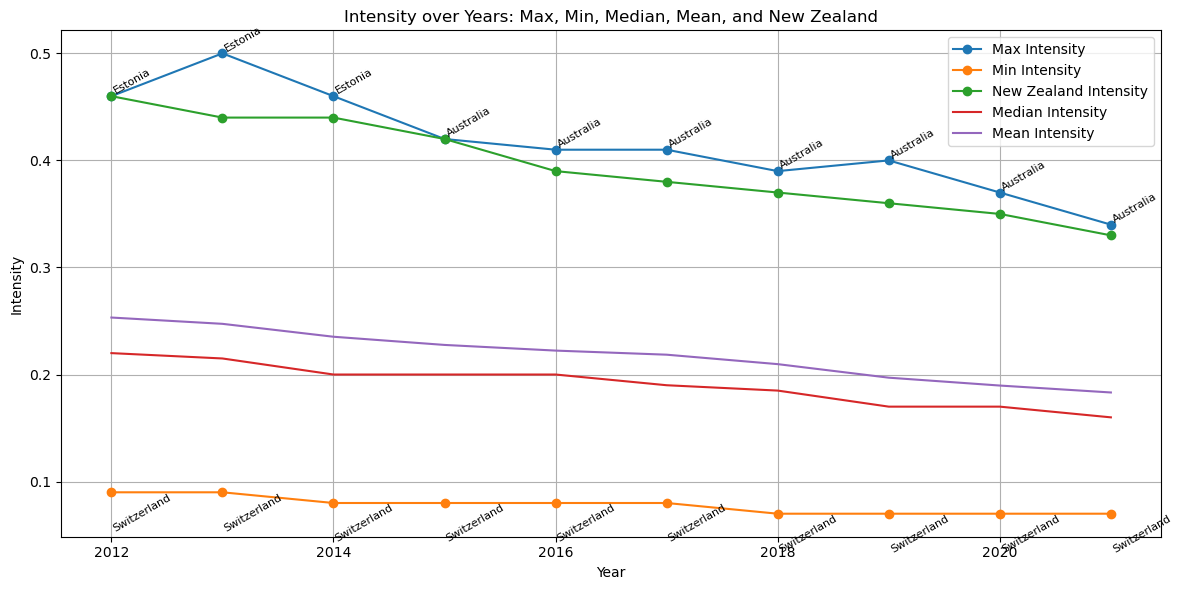

In [34]:
# Group by year
year_groups = q1_clean.groupby('Year')

# Prepare lists
years = sorted(q1_clean['Year'].unique())
max_intensity = []
min_intensity = []
median_intensity = []
mean_intensity = []
nz_intensity = []
max_countries = []
min_countries = []

for year, group in year_groups:
    max_row = group.loc[group['Intensity'].idxmax()]
    min_row = group.loc[group['Intensity'].idxmin()]
    median_value = group['Intensity'].median()
    mean_value = group['Intensity'].mean()
    nz_value = group[group['Country'] == 'New Zealand']['Intensity'].mean()  # or .iloc[0] if only one

    max_intensity.append(max_row['Intensity'])
    min_intensity.append(min_row['Intensity'])
    median_intensity.append(median_value)
    mean_intensity.append(mean_value)
    nz_intensity.append(nz_value)
    max_countries.append(max_row['Country'])
    min_countries.append(min_row['Country'])

# Plotting
plt.figure(figsize=(12, 6))

# Max, Min, NZ with markers
plt.plot(years, max_intensity, label='Max Intensity', marker='o')
plt.plot(years, min_intensity, label='Min Intensity', marker='o')
plt.plot(years, nz_intensity, label='New Zealand Intensity', marker='o')

# Median, Mean as smooth lines without markers
plt.plot(years, median_intensity, label='Median Intensity')
plt.plot(years, mean_intensity, label='Mean Intensity')

# Label max and min countries
for i, year in enumerate(years):
    plt.text(year, max_intensity[i], max_countries[i], ha='left', va='bottom', fontsize=8, rotation=30)
    plt.text(year, min_intensity[i], min_countries[i], ha='left', va='top', fontsize=8, rotation=30)

plt.xlabel('Year')
plt.ylabel('Intensity')
plt.title('Intensity over Years: Max, Min, Median, Mean, and New Zealand')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
# Use qcut for exact 4 quartile bins per year
q1_clean['Intensity_Quartile'] = (
    q1_clean.groupby('Year')['Intensity']
    .transform(lambda x: pd.qcut(x, 4, labels=['Low', 'Medium-Low', 'Medium-High', 'High']))
)

# Check the counts per group
q1_clean['Intensity_Quartile'].value_counts()

Intensity_Quartile
Low            100
High            88
Medium-Low      80
Medium-High     72
Name: count, dtype: int64

In [36]:
# Check year type
print(q1_clean['Year'].unique())  # See if years are int or str

# Assuming years are integers — adjust if needed
q1_df_2012 = q1_clean[q1_clean['Year'] == 2012].set_index('Country')
q1_df_2021 = q1_clean[q1_clean['Year'] == 2021].set_index('Country')

# Check country overlap
q1_common_countries = q1_df_2012.index.intersection(q1_df_2021.index)
print(f"Common countries: {len(q1_common_countries)}")

# Filter to only common countries
q1_df_2012 = q1_df_2012.loc[q1_common_countries]
q1_df_2021 = q1_df_2021.loc[q1_common_countries]

# Calculate percentage changes
q1_change_df = pd.DataFrame({
    'GHG_Change_%': ((q1_df_2021['GHG_Without_LULUCF_kT_CO2e'] - q1_df_2012['GHG_Without_LULUCF_kT_CO2e']) / q1_df_2012['GHG_Without_LULUCF_kT_CO2e']) * 100,
    'GDP_Change_%': ((q1_df_2021['Real_GDP_Thousand_USD'] - q1_df_2012['Real_GDP_Thousand_USD']) / q1_df_2012['Real_GDP_Thousand_USD']) * 100,
    'Intensity_Change_%': ((q1_df_2021['Intensity'] - q1_df_2012['Intensity']) / q1_df_2012['Intensity']) * 100
})

# Add country code from df_2021 (should match df_2012)
q1_change_df['Country_Code'] = q1_df_2021['Country_Code']

# Bring 'Country_Code' to the front for nicer display
q1_change_df = q1_change_df[['Country_Code', 'GHG_Change_%', 'GDP_Change_%', 'Intensity_Change_%']]

# Round values for clarity
q1_change_df = q1_change_df.round(2)

# Preview the result
print(q1_change_df.head())

[2012 2013 2014 2015 2016 2017 2018 2019 2020 2021]
Common countries: 34
            Country_Code  GHG_Change_%  GDP_Change_%  Intensity_Change_%
Country                                                                 
Australia            AUS         -4.24         27.11              -24.44
Austria              AUT         -3.17          8.43              -12.50
Belgium              BEL         -8.53         11.96              -20.00
Canada               CAN         -6.41         16.32              -20.93
Switzerland          CHE        -14.02         17.87              -22.22


In [37]:
# Sort by Intensity descending, then GDP ascending
q1_change_df_sorted = q1_change_df.sort_values(
    by=['Intensity_Change_%', 'GDP_Change_%'],
    ascending=[True, False]
)

q1_change_df_sorted

,Country_Code,GHG_Change_%,GDP_Change_%,Intensity_Change_%
Country,,,,
Estonia,EST,-36.92,33.49,-52.17
Ireland,IRL,3.50,115.95,-50.00
Luxembourg,LUX,-20.50,27.08,-38.89
United Kingdom,GBR,-26.75,12.87,-36.84
Denmark,DNK,-20.64,21.19,-35.29
Israel,ISR,-8.05,40.46,-34.48
Greece,GRC,-30.98,2.63,-32.35
Slovenia,SVN,-15.57,26.51,-32.00
Lithuania,LTU,-3.75,36.43,-30.43


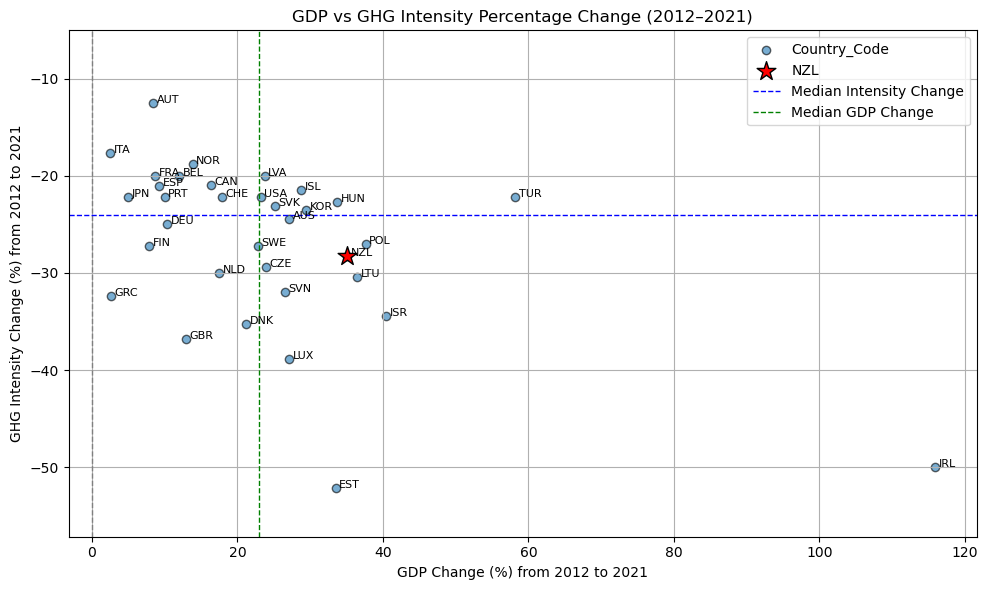

In [38]:
# Prepare the data
x = q1_change_df_sorted['GDP_Change_%']
y = q1_change_df_sorted['Intensity_Change_%']
q1_country_codes = q1_change_df_sorted['Country_Code']
q1_countries = q1_change_df_sorted.index

# Calculate medians
x_median = x.median()
y_median = y.median()

plt.figure(figsize=(10, 6))

# Plot bubbles
scatter = plt.scatter(x, y, alpha=0.6, edgecolors='k', label='Country_Code')

# Highlight New Zealand
if 'New Zealand' in q1_countries:
    nz_x = q1_change_df_sorted.loc['New Zealand', 'GDP_Change_%']
    nz_y = q1_change_df_sorted.loc['New Zealand', 'Intensity_Change_%']
    nz_code = q1_change_df_sorted.loc['New Zealand', 'Country_Code']
    plt.scatter(nz_x, nz_y, s=200, color='red', edgecolors='k', marker='*', label=nz_code, zorder=5)

# Add country code labels
for i, code in enumerate(q1_country_codes):
    plt.text(x.iloc[i] + 0.5, y.iloc[i], code, fontsize=8)

# Reference lines at 0
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# Add median lines
plt.axhline(y_median, color='blue', linestyle='--', linewidth=1, label='Median Intensity Change')
plt.axvline(x_median, color='green', linestyle='--', linewidth=1, label='Median GDP Change')

# Set y-axis limits: bottom auto, top = -5 (adjust if needed)
plt.ylim(bottom=min(y) - 5, top=-5)

# Labels and title
plt.xlabel('GDP Change (%) from 2012 to 2021')
plt.ylabel('GHG Intensity Change (%) from 2012 to 2021')
plt.title('GDP vs GHG Intensity Percentage Change (2012–2021)')

# Add legend
plt.legend()

# Grid and layout
plt.grid(True)
plt.tight_layout()
plt.show()

#### Question 2: What is the relationship between New Zealand’s transport emissions and its energy consumption compared to other OECD members?

**Key Insight:**  
To explore this, we use **correlation analysis**, which helps us understand whether two variables — in this case, **transport energy use** and **transport GHG emissions** — tend to move together, and how strongly.

Across most OECD countries, **a moderate correlation** is observed:  
> As energy consumption in transport increases, emissions also rise — but not drastically.

However, **New Zealand stands out**:
- It shows a **stronger positive correlation**, meaning that **when energy use increases, emissions rise more steeply**.
- This suggests a **more direct link** between energy consumption and emissions, possibly due to a **higher dependency on fossil fuels**.

In [39]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country_Code                      340 non-null    object 
 1   Country                           340 non-null    object 
 2   Year                              340 non-null    int64  
 3   GHG_Without_LULUCF_kT_CO2e        340 non-null    float64
 4   GHG_Transport_kT_CO2e             340 non-null    float64
 5   Energy_Consumption_Transport_Pct  340 non-null    float64
 6   Real_GDP_Thousand_USD             340 non-null    float64
 7   Transport_Added_Value_Pct         330 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 21.4+ KB


In [40]:
# Select the relevent column
q2 = combined_df[['Country_Code','Country','Year','GHG_Without_LULUCF_kT_CO2e','GHG_Transport_kT_CO2e','Energy_Consumption_Transport_Pct']].copy()
q2['GHG_Transport_Emission%'] = q2['GHG_Transport_kT_CO2e']/q2['GHG_Without_LULUCF_kT_CO2e']*100
q2_clean = q2.round(2)
q2_clean

,Country_Code,Country,Year,GHG_Without_LULUCF_kT_CO2e,GHG_Transport_kT_CO2e,Energy_Consumption_Transport_Pct,GHG_Transport_Emission%
0,AUS,Australia,2012,550595.58,91787.08,38.72,16.67
1,AUS,Australia,2013,542518.81,93134.22,38.81,17.17
2,AUS,Australia,2014,534092.04,93090.04,38.79,17.43
3,AUS,Australia,2015,543339.70,95232.48,39.30,17.53
4,AUS,Australia,2016,551588.81,96225.87,39.69,17.45
...,...,...,...,...,...,...,...
335,USA,United States,2017,6561824.44,1783274.96,40.96,27.18
336,USA,United States,2018,6754831.65,1815592.69,39.94,26.88
337,USA,United States,2019,6617916.88,1820657.45,40.21,27.51
338,USA,United States,2020,6025973.61,1574166.59,37.68,26.12


In [41]:
# Create a dictionary to store each country’s correlation
q2_country_corrs = {}

for country in q2_clean['Country'].unique():
    country_data = q2_clean[q2_clean['Country'] == country]
    
    if len(country_data) > 1:
        corr_value = country_data['GHG_Transport_Emission%'].corr(country_data['Energy_Consumption_Transport_Pct'])
        q2_country_corrs[country] = corr_value
    else:
        q2_country_corrs[country] = None  # Not enough data to calculate correlation

# Add the correlation as a new column to the dataframe
q2_clean['Transport_Energy_GHG_Corr'] = q2_clean['Country'].map(q2_country_corrs)

# Sort by correlation (highest to lowest)
sorted_corr = q2_clean.sort_values(by='Transport_Energy_GHG_Corr', ascending=True).reset_index()

# Show the sorted result
sorted_corr[['Country','Transport_Energy_GHG_Corr']]

,Country,Transport_Energy_GHG_Corr
0,Finland,-0.668974
1,Finland,-0.668974
2,Finland,-0.668974
3,Finland,-0.668974
4,Finland,-0.668974
...,...,...
335,Poland,0.988681
336,Poland,0.988681
337,Poland,0.988681
338,Poland,0.988681


In [42]:
# Get one correlation value per country by averaging (in case duplicates exist)
q2_country_avg_corr = (
    sorted_corr[['Country', 'Transport_Energy_GHG_Corr']]
    .groupby('Country', as_index=False)
    .mean()
)

# Sort from lowest to highest correlation
q2_country_avg_corr_sorted = q2_country_avg_corr.sort_values(by='Transport_Energy_GHG_Corr')

# Display the sorted table
q2_country_avg_corr_sorted.reset_index(drop=True)


,Country,Transport_Energy_GHG_Corr
0,Finland,-0.668974
1,Israel,-0.247296
2,Portugal,0.045362
3,Germany,0.245632
4,United States,0.289201
5,Denmark,0.368224
6,Spain,0.463605
7,Greece,0.463837
8,Japan,0.489572
9,United Kingdom,0.542623


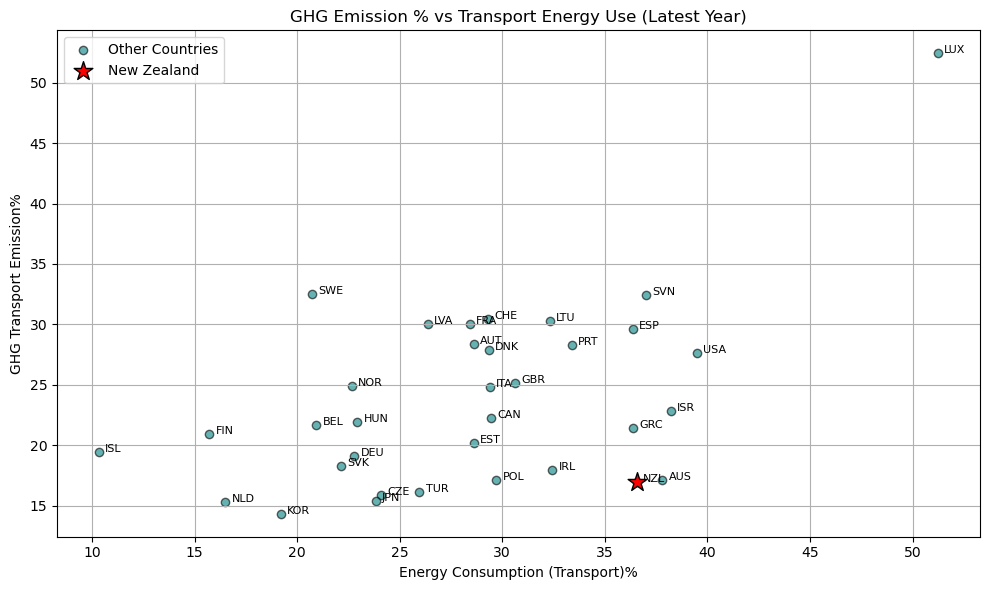

In [43]:
# Get the latest year per country to avoid clutter
latest_q2 = q2_clean.sort_values('Year').groupby('Country', as_index=False).last()

# Scatter plot with country annotations
plt.figure(figsize=(10, 6))
plt.scatter(latest_q2['Energy_Consumption_Transport_Pct'],
            latest_q2['GHG_Transport_Emission%'],
            alpha=0.6, edgecolors='k', color='teal', label='Other Countries')

# Highlight New Zealand
nz_data = latest_q2[latest_q2['Country'] == 'New Zealand']
if not nz_data.empty:
    plt.scatter(nz_data['Energy_Consumption_Transport_Pct'],
                nz_data['GHG_Transport_Emission%'],
                s=200, color='red', edgecolors='k', marker='*', label='New Zealand', zorder=5)

# Annotate each country
for i in range(len(latest_q2)):
    plt.text(latest_q2['Energy_Consumption_Transport_Pct'].iloc[i] + 0.3,
             latest_q2['GHG_Transport_Emission%'].iloc[i],
             latest_q2['Country_Code'].iloc[i], fontsize=8)

# Plot formatting
plt.title('GHG Emission % vs Transport Energy Use (Latest Year)')
plt.xlabel('Energy Consumption (Transport)%')
plt.ylabel('GHG Transport Emission%')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



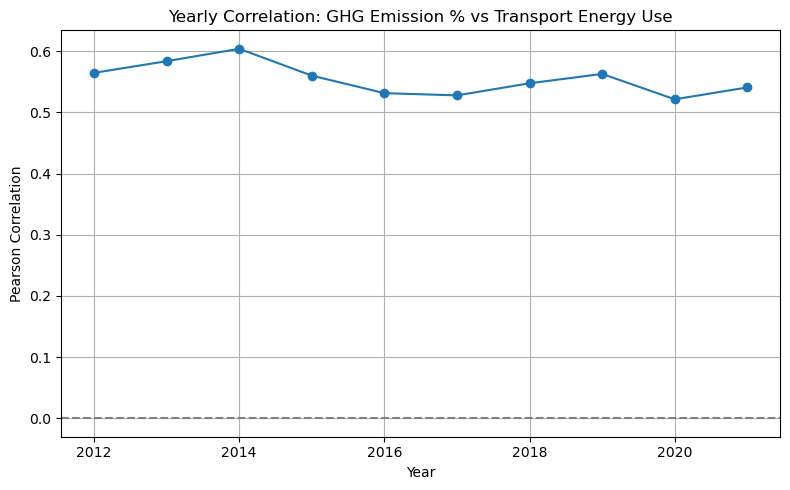

In [44]:
# Calculate correlation for each year across all countries
yearly_corrs = []

for year in sorted(q2_clean['Year'].dropna().unique()):
    temp = q2_clean[q2_clean['Year'] == year]
    temp = temp[['GHG_Transport_Emission%', 'Energy_Consumption_Transport_Pct']].dropna()
    if len(temp) >= 2:
        corr_val = temp.corr().iloc[0, 1]
        yearly_corrs.append({'Year': year, 'Correlation': corr_val})

# Convert to DataFrame and plot
yearly_corr_df = pd.DataFrame(yearly_corrs)

plt.figure(figsize=(8, 5))
plt.plot(yearly_corr_df['Year'], yearly_corr_df['Correlation'], marker='o')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Yearly Correlation: GHG Emission % vs Transport Energy Use')
plt.xlabel('Year')
plt.ylabel('Pearson Correlation')
plt.grid(True)
plt.tight_layout()
plt.show()


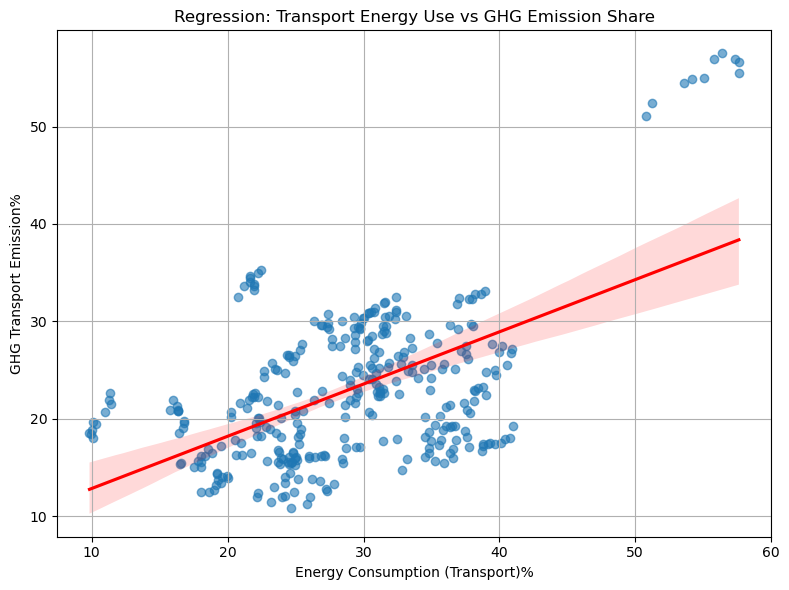

In [45]:
# Drop missing values for regression plot
reg_data = q2_clean[['GHG_Transport_Emission%', 'Energy_Consumption_Transport_Pct']].dropna()

plt.figure(figsize=(8, 6))
sns.regplot(data=reg_data,
            x='Energy_Consumption_Transport_Pct',
            y='GHG_Transport_Emission%',
            scatter_kws={'alpha':0.6},
            line_kws={'color': 'red'})

plt.title('Regression: Transport Energy Use vs GHG Emission Share')
plt.xlabel('Energy Consumption (Transport)%')
plt.ylabel('GHG Transport Emission%')
plt.grid(True)
plt.tight_layout()
plt.show()


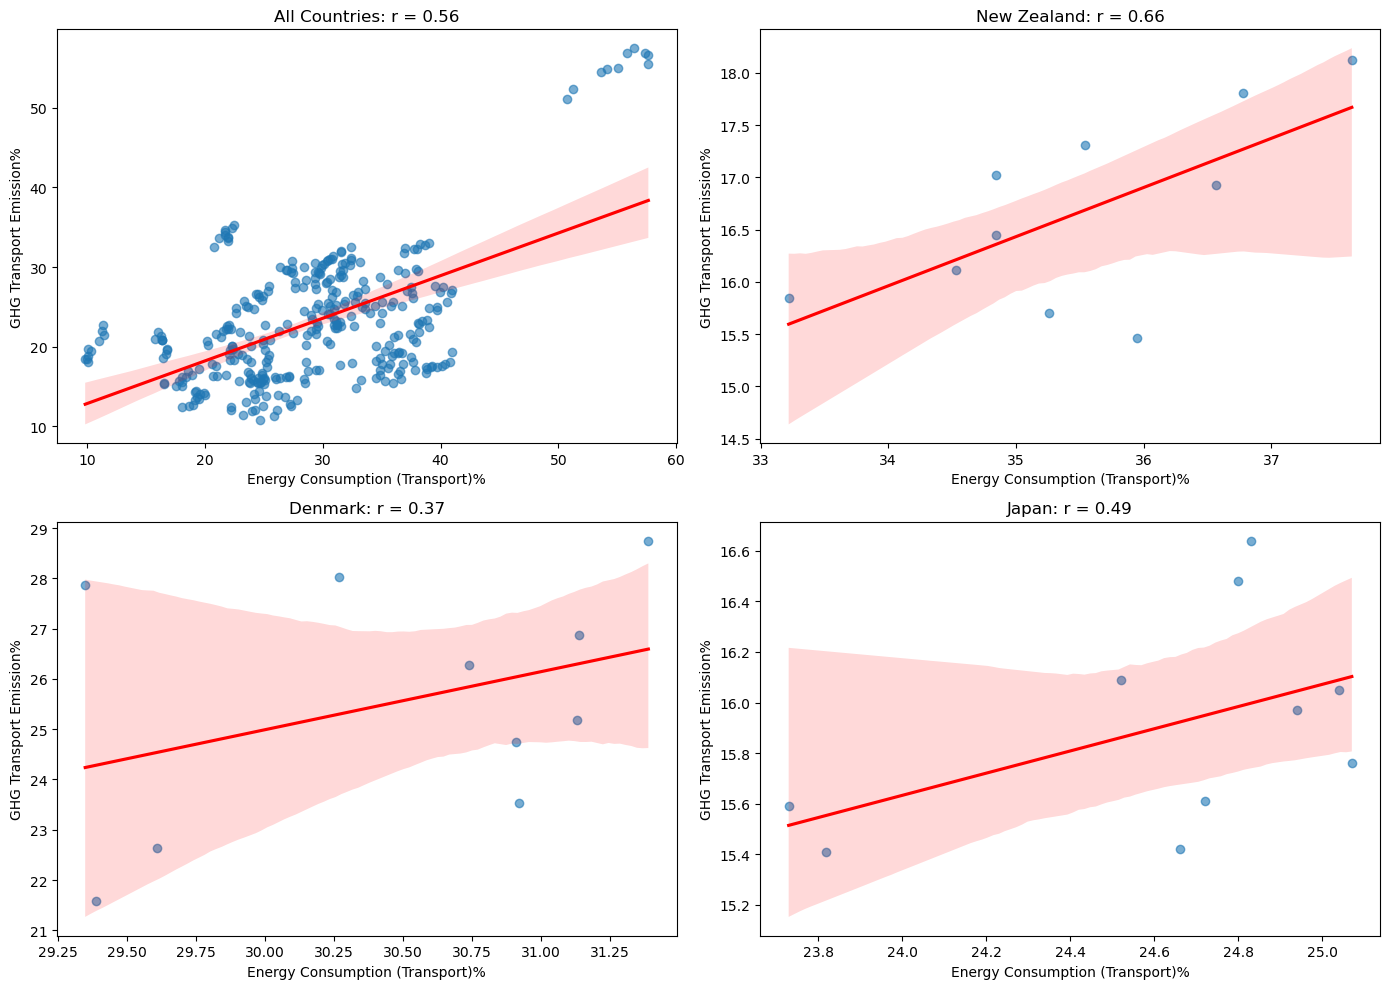

In [46]:
# Prepare your list of countries (use "All" as label for full dataset)
plot_targets = ['All', 'New Zealand', 'Denmark', 'Japan',]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Loop through each target
for i, target in enumerate(plot_targets):
    if target == 'All':
        data = q2_clean[['GHG_Transport_Emission%', 'Energy_Consumption_Transport_Pct']].dropna()
        title = 'All Countries'
    else:
        data = q2_clean[q2_clean['Country'] == target][['GHG_Transport_Emission%', 'Energy_Consumption_Transport_Pct']].dropna()
        title = target

    if not data.empty and len(data) >= 2:
        sns.regplot(
            data=data,
            x='Energy_Consumption_Transport_Pct',
            y='GHG_Transport_Emission%',
            scatter_kws={'alpha': 0.6},
            line_kws={'color': 'red'},
            ax=axes[i]
        )
        axes[i].set_title(f'{title}: r = {data.corr().iloc[0, 1]:.2f}')
    else:
        axes[i].text(0.5, 0.5, f'Not enough data for {title}', ha='center', va='center')
        axes[i].set_axis_off()

# Layout & final touches
for ax in axes:
    ax.set_xlabel('Energy Consumption (Transport)%')
    ax.set_ylabel('GHG Transport Emission%')
plt.tight_layout()
plt.show()




#### Question 3: How Efficient Is New Zealand in Generating Economic Output per Unit of Transport Emissions Compared to Other OECD Countries?

To evaluate transport sector efficiency, this analysis examines how much economic output (GDP) is generated per unit of greenhouse gas (GHG) emissions. A lower GHG intensity indicates better environmental and economic performance, as it reflects a country's ability to decouple economic growth from emissions.

New Zealand performs poorly in this aspect. Despite high energy consumption in the transport sector, the country generates relatively low economic output per unit of emissions compared to most OECD members. This suggests an inefficient use of energy resources within the transport system.

In contrast, countries such as **Denmark**, **Finland**, and **Germany** demonstrate stronger performance. These countries exhibit both:
- A weaker correlation between energy consumption and emissions, indicating effective emissions control measures, and
- Higher GDP output per unit of transport emissions, reflecting better economic returns for environmental costs.

These findings highlight the opportunity for New Zealand to improve transport-related efficiency by adopting cleaner energy sources and enhancing the productivity of its transport sector.


In [47]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country_Code                      340 non-null    object 
 1   Country                           340 non-null    object 
 2   Year                              340 non-null    int64  
 3   GHG_Without_LULUCF_kT_CO2e        340 non-null    float64
 4   GHG_Transport_kT_CO2e             340 non-null    float64
 5   Energy_Consumption_Transport_Pct  340 non-null    float64
 6   Real_GDP_Thousand_USD             340 non-null    float64
 7   Transport_Added_Value_Pct         330 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 21.4+ KB


In [48]:
# Create a copy of the dataset for analysis
q3 = combined_df[['Country_Code','Country','Year','GHG_Transport_kT_CO2e','GHG_Without_LULUCF_kT_CO2e','Energy_Consumption_Transport_Pct','Real_GDP_Thousand_USD','Transport_Added_Value_Pct']].copy()

In [49]:
# Calculate new variables
q3['Real_GDP_Transport'] = q3['Real_GDP_Thousand_USD'] * (q3['Transport_Added_Value_Pct'] / 100)
q3['GHG_Transport_Emission%'] = q3["GHG_Transport_kT_CO2e"]/q3["GHG_Without_LULUCF_kT_CO2e"]*100
q3['Transport_GHG_Intensity'] = (q3['GHG_Transport_kT_CO2e'] * 1000)/q3['Real_GDP_Transport'] 
q3

,Country_Code,Country,Year,GHG_Transport_kT_CO2e,GHG_Without_LULUCF_kT_CO2e,Energy_Consumption_Transport_Pct,Real_GDP_Thousand_USD,Transport_Added_Value_Pct,Real_GDP_Transport,GHG_Transport_Emission%,Transport_GHG_Intensity
0,AUS,Australia,2012,9.178708e+04,5.505956e+05,38.72,1.212209e+09,5.226109,6.335138e+07,16.670508,1.448857
1,AUS,Australia,2013,9.313422e+04,5.425188e+05,38.81,1.244610e+09,5.054437,6.290804e+07,17.167002,1.480482
2,AUS,Australia,2014,9.309004e+04,5.340920e+05,38.79,1.260654e+09,5.171628,6.519635e+07,17.429588,1.427841
3,AUS,Australia,2015,9.523248e+04,5.433397e+05,39.30,1.296142e+09,5.204083,6.745229e+07,17.527244,1.411849
4,AUS,Australia,2016,9.622587e+04,5.515888e+05,39.69,1.361663e+09,5.074861,6.910251e+07,17.445218,1.392509
...,...,...,...,...,...,...,...,...,...,...,...
335,USA,United States,2017,1.783275e+06,6.561824e+06,40.96,2.066751e+10,3.349004,6.921557e+08,27.176511,2.576407
336,USA,United States,2018,1.815593e+06,6.754832e+06,39.94,2.128061e+10,3.376651,7.185718e+08,26.878430,2.526669
337,USA,United States,2019,1.820657e+06,6.617917e+06,40.21,2.182444e+10,3.396151,7.411909e+08,27.511035,2.456395
338,USA,United States,2020,1.574167e+06,6.025974e+06,37.68,2.135410e+10,3.062731,6.540187e+08,26.123025,2.406914


In [50]:
# Initialize an empty dictionary
q3_country_corrs = {}

# Loop over each country to calculate correlation
for country in q3['Country'].unique():
    country_data = q3[q3['Country'] == country]
    
    if len(country_data) > 1:
        corr_value = country_data['GHG_Transport_Emission%'].corr(country_data['Energy_Consumption_Transport_Pct'])
        q3_country_corrs[country] = corr_value
    else:
        q3_country_corrs[country] = None  # Not enough data

# Map correlation back into the dataframe
q3['Transport_Energy_GHG_Corr'] = q3['Country'].map(q3_country_corrs)

# Preview result
q3.drop_duplicates()

,Country_Code,Country,Year,GHG_Transport_kT_CO2e,GHG_Without_LULUCF_kT_CO2e,Energy_Consumption_Transport_Pct,Real_GDP_Thousand_USD,Transport_Added_Value_Pct,Real_GDP_Transport,GHG_Transport_Emission%,Transport_GHG_Intensity,Transport_Energy_GHG_Corr
0,AUS,Australia,2012,9.178708e+04,5.505956e+05,38.72,1.212209e+09,5.226109,6.335138e+07,16.670508,1.448857,0.822869
1,AUS,Australia,2013,9.313422e+04,5.425188e+05,38.81,1.244610e+09,5.054437,6.290804e+07,17.167002,1.480482,0.822869
2,AUS,Australia,2014,9.309004e+04,5.340920e+05,38.79,1.260654e+09,5.171628,6.519635e+07,17.429588,1.427841,0.822869
3,AUS,Australia,2015,9.523248e+04,5.433397e+05,39.30,1.296142e+09,5.204083,6.745229e+07,17.527244,1.411849,0.822869
4,AUS,Australia,2016,9.622587e+04,5.515888e+05,39.69,1.361663e+09,5.074861,6.910251e+07,17.445218,1.392509,0.822869
...,...,...,...,...,...,...,...,...,...,...,...,...
335,USA,United States,2017,1.783275e+06,6.561824e+06,40.96,2.066751e+10,3.349004,6.921557e+08,27.176511,2.576407,0.287832
336,USA,United States,2018,1.815593e+06,6.754832e+06,39.94,2.128061e+10,3.376651,7.185718e+08,26.878430,2.526669,0.287832
337,USA,United States,2019,1.820657e+06,6.617917e+06,40.21,2.182444e+10,3.396151,7.411909e+08,27.511035,2.456395,0.287832
338,USA,United States,2020,1.574167e+06,6.025974e+06,37.68,2.135410e+10,3.062731,6.540187e+08,26.123025,2.406914,0.287832


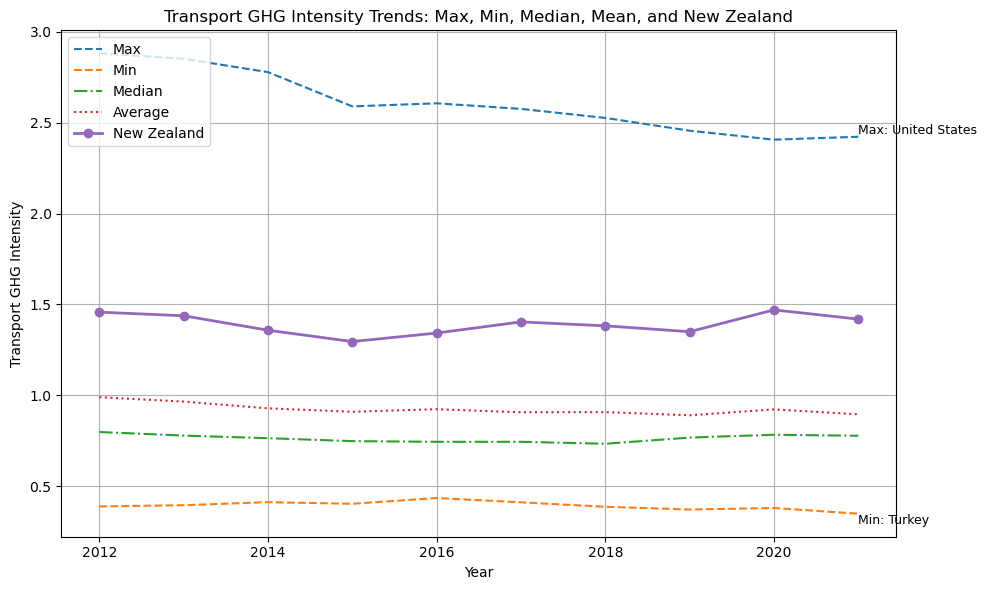

In [51]:
# Calculate summary statistics per year
q3_summary = q3.groupby('Year').agg({
    'Transport_GHG_Intensity': ['max', 'min', 'median', 'mean']
}).reset_index()
q3_summary.columns = ['Year', 'Max', 'Min', 'Median', 'Mean']

# Find countries with max and min in the latest year
q3_latest_year = q3['Year'].max()
q3_latest_data = q3[q3['Year'] == q3_latest_year]
q3_max_country = q3_latest_data.loc[q3_latest_data['Transport_GHG_Intensity'].idxmax(), 'Country']
q3_min_country = q3_latest_data.loc[q3_latest_data['Transport_GHG_Intensity'].idxmin(), 'Country']

# Prepare plot
plt.figure(figsize=(10, 6))
plt.plot(q3_summary['Year'], q3_summary['Max'], linestyle='--', label='Max')
plt.plot(q3_summary['Year'], q3_summary['Min'], linestyle='--', label='Min')
plt.plot(q3_summary['Year'], q3_summary['Median'], linestyle='-.', label='Median')
plt.plot(q3_summary['Year'], q3_summary['Mean'], linestyle=':', label='Average')

# Plot New Zealand
q3_nz_data = q3[q3['Country'] == 'New Zealand']
plt.plot(q3_nz_data['Year'], q3_nz_data['Transport_GHG_Intensity'], label='New Zealand', marker='o', linewidth=2)

# Add text labels directly on the Max and Min lines (latest year)
plt.text(
    x=q3_latest_year,
    y=q3_summary.loc[q3_summary['Year'] == q3_latest_year, 'Max'].values[0],
    s=f'Max: {q3_max_country}',
    fontsize=9,
    color='black',
    verticalalignment='bottom'
)
plt.text(
    x=q3_latest_year,
    y=q3_summary.loc[q3_summary['Year'] == q3_latest_year, 'Min'].values[0],
    s=f'Min: {q3_min_country}',
    fontsize=9,
    color='black',
    verticalalignment='top'
)

# Labels and legend
plt.xlabel('Year')
plt.ylabel('Transport GHG Intensity')
plt.title('Transport GHG Intensity Trends: Max, Min, Median, Mean, and New Zealand')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [52]:
# Group by country and calculate averages
q3_country_avg = q3.groupby('Country').agg({
    'Transport_GHG_Intensity': 'mean',
    'Transport_Energy_GHG_Corr': 'mean'
}).reset_index()

# sort by intensity or correlation if you want
q3_country_avg_sorted = q3_country_avg.sort_values(by='Transport_GHG_Intensity', ascending=False)

# Display the result
q3_country_avg_sorted.reset_index(drop=True)

,Country,Transport_GHG_Intensity,Transport_Energy_GHG_Corr
0,United States,2.609979,0.287832
1,Canada,1.949903,0.809464
2,Luxembourg,1.755783,0.905813
3,Australia,1.431690,0.822869
4,New Zealand,1.391676,0.658427
5,Ireland,1.345486,0.802084
6,Korea,1.057014,0.756442
7,Slovenia,1.055242,0.734144
8,Spain,0.981728,0.463532
9,Portugal,0.937859,0.045842


In [53]:

# Get New Zealand's averages
q3_nz_row = q3_country_avg[q3_country_avg['Country'] == 'New Zealand']
q3_nz_avg_intensity = q3_nz_row['Transport_GHG_Intensity'].values[0]
q3_nz_avg_corr = q3_nz_row['Transport_Energy_GHG_Corr'].values[0]

# Add comparison columns
q3_country_avg['Lower_GHG_Intensity_Than_NZ'] = q3_country_avg['Transport_GHG_Intensity'] < q3_nz_avg_intensity
q3_country_avg['Weaker_Correlation_Than_NZ'] = q3_country_avg['Transport_Energy_GHG_Corr'] < q3_nz_avg_corr

# Sort the table
q3_country_avg_sorted = q3_country_avg.sort_values(by='Transport_GHG_Intensity', ascending=True)

# Display the result
q3_country_avg_sorted.reset_index(drop=True)

,Country,Transport_GHG_Intensity,Transport_Energy_GHG_Corr,Lower_GHG_Intensity_Than_NZ,Weaker_Correlation_Than_NZ
0,Turkey,0.393435,0.901609,True,False
1,Lithuania,0.443349,0.976206,True,False
2,Latvia,0.578635,0.929687,True,False
3,Sweden,0.598101,0.734031,True,False
4,Netherlands,0.603322,0.660680,True,False
5,Hungary,0.631502,0.943692,True,False
6,Denmark,0.642070,0.368333,True,True
7,Slovak Republic,0.643710,0.815975,True,False
8,Switzerland,0.646399,0.962040,True,False
9,Estonia,0.655123,0.718249,True,False


In [54]:
# Countries that perform better than New Zealand in both:
# 1. Emitting fewer GHGs per unit of energy used in transport (lower GHG intensity)
# 2. Showing a weaker correlation between GHG intensity and GDP output from transport,
#    suggesting greater decoupling of emissions from economic activity

batch1 = q3_country_avg.loc[
    (q3_country_avg['Lower_GHG_Intensity_Than_NZ'] == True) & 
    (q3_country_avg['Weaker_Correlation_Than_NZ'] == True)
]

batch1


,Country,Transport_GHG_Intensity,Transport_Energy_GHG_Corr,Lower_GHG_Intensity_Than_NZ,Weaker_Correlation_Than_NZ
5,Denmark,0.642070,0.368333,True,True
7,Finland,0.836049,-0.669055,True,True
9,Germany,0.724467,0.244269,True,True
10,Greece,0.802386,0.463665,True,True
16,Japan,0.735596,0.491794,True,True
25,Portugal,0.937859,0.045842,True,True
28,Spain,0.981728,0.463532,True,True
32,United Kingdom,0.917980,0.542130,True,True


In [55]:
# Countries that perform better than New Zealand in GHG intensity 
# BUT show a stronger correlation between transport GHG and GDP,
# suggesting their transport emissions are still more closely tied to economic activity.

batch2 = q3_country_avg.loc[
    (q3_country_avg['Lower_GHG_Intensity_Than_NZ'] == True) & 
    (q3_country_avg['Weaker_Correlation_Than_NZ'] == False)
]

batch2


,Country,Transport_GHG_Intensity,Transport_Energy_GHG_Corr,Lower_GHG_Intensity_Than_NZ,Weaker_Correlation_Than_NZ
1,Austria,0.786262,0.787840,True,False
2,Belgium,0.698388,0.915272,True,False
4,Czechia,0.708089,0.727585,True,False
6,Estonia,0.655123,0.718249,True,False
8,France,0.847568,0.769724,True,False
11,Hungary,0.631502,0.943692,True,False
12,Iceland,0.838054,0.945359,True,False
13,Ireland,1.345486,0.802084,True,False
15,Italy,0.733215,0.687975,True,False
17,Korea,1.057014,0.756442,True,False


### 5. LIMITATIONS

To evaluate how technologies impact transport emissions, we must go beyond basic metrics like emission intensities, GDP, or energy consumption. While these indicators offer useful macro-level trends, they fall short in explaining how specific technologies function or what problems they address. Unfortunately, the dataset we are working with lacks the necessary technical detail — such as information on specific innovations, mechanisms, or implementation contexts — to support this deeper level of analysis. As a result, our insights remain at an aggregate level and cannot fully capture the direct role of technology in reducing emissions.

Understanding technological progress is essential when evaluating efforts to reduce transport emissions because technology plays a central role in shaping how energy is consumed and emissions are generated. Innovations such as electric vehicles, fuel-efficient engines, intelligent transport systems, and alternative fuels offer targeted solutions that directly alter the emissions profile of the transport sector. Unlike broad economic indicators like GDP or aggregate energy consumption, which reflect outcomes, technological advancements represent the underlying drivers of change. They determine the pace, scale, and sustainability of emissions reductions. Without insight into how specific technologies are developed, adopted, and integrated into transport systems, it is difficult to assess the effectiveness of policy interventions or predict future trends. Moreover, technology diffusion varies widely across regions and income levels, influencing both the feasibility and impact of decarbonization strategies. Therefore, a nuanced understanding of technology progress provides the necessary context for interpreting emission trends and designing evidence-based, forward-looking solutions.

#### Question 4: How do the best countries control their transport emissions effectively through innovative technologies?”

To better understand how technologies impact transport emissions, we turn to patent documents, which offer detailed technical insights into how these innovations have been developed and the specific problems they aim to address.

The Google Patents website is a publicly accessible, information-rich resource that provides access to a vast collection of global patent documents. Relevant patents can be located by searching with targeted keywords related to the technology of interest. Once a search is performed, Google Patents returns a list of matching documents, each identified by a unique patent document number — this might be a granted patent number, a patent application number, or a publication number.

With this document number, we can directly access the full, detailed description of the invention, including technical specifications, problem statements, and potential applications. This enables systematic extraction of valuable insights from the patent, supporting deeper analysis of the technologies driving innovation in transport emission control.

To perform a Google Patents search programmatically, we propose the use of web scraping solution by using the web driver provided by the Selenium package. Selenium’s web driver enables the automation of browser actions, effectively simulating human interactions with the website. This approach helps avoid detection and rejection by the site’s anti-bot mechanisms, ensuring that search queries are processed as if they were made by a regular user.

Figure 1 shows the screen shot of the Firefox web browser when the web driver is crawling.

![Screenshot](https://raw.githubusercontent.com/sbnz496/group9_701/main/Screenshot.jpg)

*Acknowledgement: Parts of this Python script came from the University of Auckland BUSINFO701 class's lecture and lab sessions.*

In [56]:
# Selenium version 4 is required for this script.
# Install Selenium via Anaconda first.
# Then, download the webdriver from the following url: https://github.com/mozilla/geckodriver/releases

from selenium import webdriver
from selenium.webdriver.firefox.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.firefox.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# Specify search parameters here.
search_engine_url = 'https://patents.google.com/'       # Search website url (Google Patents)
keywords = 'emission reduce renewable energy transport denmark'     # Search keywords
search_wait_time = 10                                   # Waiting time for search returns in minutes
file_name = 'search_result.html'                        # File name for HTML record

options = Options()
options.binary_location = '/Applications/Firefox.app/Contents/MacOS/Firefox'  # Standard Mac path (change this to your device)

# Use the absolute path to the Mac geckodriver (no .exe)
service = Service('/usr/local/bin/geckodriver')

driver = webdriver.Firefox(service=service, options=options)

# Specify the browser size, search engine url, and keywords to the web driver
driver.set_window_size(1120, 550)
driver.get(search_engine_url)
driver.find_element(By.ID,'searchInput').send_keys(keywords)
driver.find_element(By.ID,'searchButton').click()

# Add wait time up for search returns to appear on the browser
wait = WebDriverWait(driver, search_wait_time)
wait.until(EC.presence_of_element_located((By.CLASS_NAME,'search-result-item')))

# Extract html source from the return from the Google Patents website
html = driver.page_source

# Write the html source to local drive
with open(file_name,'w') as f:
    f.write(html)

# Exit web driver
driver.quit()

# Print output when completed
print('Google Patents search is completed. The HTML result is save to {}'.format(file_name))

Google Patents search is completed. The HTML result is save to search_result.html


Once we perform the Google Patents search, we obtain an HTML file containing the HTML source code of Google’s search result page. We then need to extract the patent document numbers embedded in the resulting page.

To do this, we use the BeautifulSoup class from the bs4 package to search for the HTML tags that contain the patent document numbers. By inspecting the web browser, we found that the patent document numbers are listed inside the &lt;a&gt; tag in the &lt;H4&gt; section under the class 'PDFLINK'. We therefore use a BeautifulSoup object to search for the patent document numbers returned from the Google Patents search.

In [57]:
# Import the class BeautifulSoup from the package bs4
from bs4 import BeautifulSoup

# Parse it with BeautifulSoup
soup = BeautifulSoup(html, 'html.parser')

# Find all <h4> tags
h4_tags = soup.find_all('h4')

# Extract patent number
patent_number = []
for h4 in h4_tags:
    # Inside <h4>, look for <a> tag with 'PDFLINK' class
    a_tag = h4.find('a', class_='pdfLink')
    if a_tag:
        # Inside <a>, get the <span> text
        span_tag = a_tag.find('span')
        if span_tag:
            patent_number.append(span_tag.text.strip())

# Print the list of patent document numbers
print('The list of patent document numbers is as follows:')
patent_number

The list of patent document numbers is as follows:


['CN110513675A',
 'CN111156499A',
 'US7974714B2',
 'AU2014101380A4',
 'US10577248B2',
 'US12078370B2',
 'US8019634B2',
 'CN205028060U',
 'US10402753B2',
 'US10656306B2']

The next step is to get an individual patent document information based on the document number obtained in the previous step. Since we want to capture all important information from the document, we utilize [Google-Patent-Scraper](https://pypi.org/project/google-patent-scraper/) package for this purpose.

If your machine does not have Google-Patent-Scraper installed, run `pip install google-patent-scraper`.

In [58]:
# Import Google-Patent-Scraper package
from google_patent_scraper import scraper_class

# Initialize a scraper object
scraper=scraper_class(return_abstract=True)

# Extract patent information for each patent document from the list of document numbers.
patent_records = []
for pat in patent_number:
    err, soup, url = scraper.request_single_patent(pat)
    patent_parsed = scraper.get_scraped_data(soup,pat,url)
    patent_records.append(patent_parsed)

# Print the list of patent information
print('The list of patent information is as follows:')
patent_records

https://patents.google.com/patent/CN110513675A
https://patents.google.com/patent/CN111156499A
https://patents.google.com/patent/US7974714B2
https://patents.google.com/patent/AU2014101380A4
https://patents.google.com/patent/US10577248B2
https://patents.google.com/patent/US12078370B2
https://patents.google.com/patent/US8019634B2
https://patents.google.com/patent/CN205028060U
https://patents.google.com/patent/US10402753B2
https://patents.google.com/patent/US10656306B2
The list of patent information is as follows:


[{'inventor_name': '[{"inventor_name": "\\u59da\\u5b97\\u8def"}, {"inventor_name": "\\u8d3e\\u5409\\u79c0"}, {"inventor_name": "\\u8d75\\u7acb\\u6b23"}, {"inventor_name": "\\u90dd\\u5148\\u8363"}, {"inventor_name": "\\u9093\\u4e91"}, {"inventor_name": "\\u4e1b\\u5b8f\\u658c"}, {"inventor_name": "\\u8d75\\u4e9a\\u7537"}]',
  'assignee_name_orig': '[{"assignee_name": "Institute of Environment and Sustainable Development in Agriculturem of CAAS"}]',
  'assignee_name_current': '[{"assignee_name": "\\n    Institute of Environment and Sustainable Development in Agriculturem of CAAS\\n  "}]',
  'pub_date': '2019-11-29',
  'priority_date': '2019-09-27',
  'grant_date': '2020-10-02',
  'filing_date': '',
  'forward_cite_no_family': '[{"patent_number": "CN111059525A", "priority_date": "2020-02-24", "pub_date": "2020-04-24"}, {"patent_number": "CN111076163A", "priority_date": "2019-12-30", "pub_date": "2020-04-28"}, {"patent_number": "CN111156499A", "priority_date": "2020-02-24", "pub_date": "202

We can use information from patent documents for further analysis, such as examining a company’s application trends to understand its investment in greenhouse gas reduction, or identifying the technological areas the company has been focusing on.